## **X6**: TT - Searching for a Quantum Advantage
* October 7°, 2026
#### ESCOM - IPN:

#### *B.S. in Computer Science*
> Miguel Alexander Sanchez Garcia

#### **0° Introduction**

The preregistered design found no advantage (H-039 to H-043), and X4 showed that a quantum kernel SVM on that design only matches a classical SVM. This notebook asks the question the other way round: **with the tools that the literature itself proposes, can a quantum model do better than a classical one on these data?** It is exploratory and post hoc, so its protocol is built to prevent the search from producing an advantage by chance.

**Quantum candidates.** All use the same 12 angles of Module 4.

| Family | Circuit | Why it might help |
|---|---|---|
| ZZ full | `zz_feature_map`, full entanglement, 1 repetition | The preregistered C4, as reference |
| ZZ full, reps 2 | the same with 2 repetitions | The IQP embedding as originally proposed by Havlíček et al. |
| ZZ linear | `zz_feature_map`, linear entanglement | Each qubit enters 2 pairs instead of 11, so its phase moves about six times more slowly (H-031). That attacks concentration while keeping the products $x_ix_j$ of neighbouring features |
| ZZ linear, reps 2 | the same with 2 repetitions | More expressive, with the same advantage against concentration |
| Projected (ZZ full / ZZ linear) | Gaussian kernel on the one-qubit reduced states $\langle X_k\rangle,\langle Y_k\rangle,\langle Z_k\rangle$ of the encoded state | The proposal of Huang et al. (eq. 9 and L6) to recover a large geometric difference when the fidelity kernel concentrates |

The fidelity kernels are evaluated on the angle scales $c\in\{1,0.5,0.2,0.1,0.05,0.02\}$ (D-029), or $\{1,0.2,0.05\}$ for the two-repetition maps. The projected kernels use five bandwidths.

**Classical candidates.** Gaussian kernels with the nine bandwidths of D-032, the linear kernel, and polynomial kernels of degree 2 and 3.

**Protocol.**

- **Same classifier for every kernel.** An SVM with balanced class weights and $C=1$; X4 showed that $C$ barely changes the result.
- **Nested cross-validation.** The outer folds are those of Module 4. Inside each training part, 3 folds grouped by patient choose the kernel and its hyperparameter. Both sides get the same search, so neither is favoured.
- **Two global contenders.** *Classical (all)* chooses among every classical candidate and *Quantum (all)* among every quantum candidate, with the same rule.
- **The test split is used once**, for the two global contenders, with the patient bootstrap of D-036.

**Two theoretical measurements.**

- The **geometric difference** (D-032) and the **effective dimension** of the new encodings, on the 200 lesions of Module 6.
- The **construction of Appendix G** of Huang et al. It builds the labels that maximize the separation between a quantum and a classical kernel on these same lesions. In their words, *"if there is no quantum advantage in this dataset, there will likely be none"*. Comparing those labels with the real ones tells how much of the possible advantage the diagnosis could use.

#### **1° Setup**

In [1]:
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qiskit
import sklearn
from qiskit.circuit.library import zz_feature_map
from qiskit.quantum_info import SparsePauliOp, Statevector
from scipy.linalg import eigh
from scipy.stats import rankdata
from sklearn.metrics import pairwise_distances, roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.svm import SVC

warnings.filterwarnings('ignore')
SEED, N_FOLDS, N_INNER, N_BOOT = 42, 5, 3, 2000
FINDINGS = ['mass', 'calcification']
TITLES = {'mass': 'Masses', 'calcification': 'Calcifications'}
SCALES = [1.0, 0.5, 0.2, 0.1, 0.05, 0.02]
MULTIPLIERS = [0.25, 0.5, 1, 2, 4, 8, 16, 32, 64]
C_GRID = [1.0]                                   # X4 (2°d): C barely changes the result
SCALES_R2 = [1.0, 0.2, 0.05]                      # shorter grid for the two-repetition maps
PROJ_MULT = [0.25, 1, 4, 16, 64]                  # bandwidths of the projected kernels
LAMBDAS = [1e-5, 1e-4, 1e-3, 1e-2, 0.025, 0.05, 0.1]
EXTENDED = [128, 256, 512]
G_TRA_MAX = 0.045
X_COLUMNS = [f'x_{i:02d}' for i in range(1, 13)]
ROOT = Path('/Users/alexander_san/TT')
M4_DIR, M5_DIR = ROOT / 'Data/processed/m4', ROOT / 'Data/processed/m5'
RESULTS_DIR, FIG_DIR = ROOT / 'Code/results', ROOT / 'Docs/Figures'
FEATURE_MAPS = {'ZZ full': zz_feature_map(12, reps=1, entanglement='full'),
                'ZZ full, reps 2': zz_feature_map(12, reps=2, entanglement='full'),
                'ZZ linear': zz_feature_map(12, reps=1, entanglement='linear'),
                'ZZ linear, reps 2': zz_feature_map(12, reps=2, entanglement='linear')}
CLASSICAL_FAMILIES = ['Gaussian', 'Linear', 'Polynomial']
QUANTUM_FAMILIES = list(FEATURE_MAPS) + ['Projected (ZZ full)', 'Projected (ZZ linear)']
COLORS = {'Classical (all)': '#2a78d6', 'Quantum (all)': '#eb6834'}
INK = '#3d3d3a'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.25, 'lines.linewidth': 2, 'lines.markersize': 8})
data = {}
for ft in FINDINGS:
    d4 = pd.read_parquet(M4_DIR / f'x_{ft}.parquet')
    data[ft] = {'frame': d4, 'X': d4[X_COLUMNS].to_numpy(float), 'y': d4.label.to_numpy(int), 'folds': d4.fold.to_numpy(int),
                'train': d4.split.eq('train').to_numpy(), 'test': d4.split.eq('test').to_numpy(),
                'patients': d4.patient_id.to_numpy()}
for name, fm in FEATURE_MAPS.items():
    ops = fm.decompose().count_ops()
    print(f"{name:18s}: {ops.get('cx', 0)} CX, depth {fm.decompose().depth()}")
print(f'qiskit {qiskit.__version__} | scikit-learn {sklearn.__version__} | numpy {np.__version__}')

ZZ full           : 132 CX, depth 65
ZZ full, reps 2   : 264 CX, depth 103
ZZ linear         : 22 CX, depth 35
ZZ linear, reps 2 : 44 CX, depth 43
qiskit 2.3.0 | scikit-learn 1.7.2 | numpy 2.2.6


In [2]:
# Metric functions copied verbatim from Code/6_Separability.ipynb (2°b), for the geometric difference and the dimension.
def sym(a):
    return (a + a.T) / 2


def normalize_trace(k):
    # Huang et al. assume Tr(K) = N (eq. 5)
    return k * len(k) / np.trace(k)


def psd_sqrt(k):
    # symmetric square root from the eigendecomposition; round-off negative eigenvalues are set to 0
    t, v = eigh(sym(k))
    return (v * np.sqrt(np.clip(t, 0, None))) @ v.T


def top_eigenvalue(m):
    return float(eigh(sym(m), eigvals_only=True)[-1])


def geometric_difference(kq, kc, lambdas):
    # g(K_C || K_Q): eq. (F19) for g_gen and eq. (F20) for g_tra; lambda = 0 gives the unregularized eq. (5)
    sq = psd_sqrt(kq)
    t, v = eigh(sym(kc))
    t = np.clip(t, 0, None)
    out = {}
    for lam in lambdas:
        if lam == 0:
            out[lam] = (np.sqrt(top_eigenvalue(sq @ ((v / t) @ v.T) @ sq)), 0.0) if t.min() > 0 else (np.inf, 0.0)
        else:
            gen = (v * (t / (t + lam) ** 2)) @ v.T          # sqrt(K_C) (K_C + lam I)^-2 sqrt(K_C)
            tra = (v * (1 / (t + lam) ** 2)) @ v.T          # (K_C + lam I)^-2
            out[lam] = (np.sqrt(top_eigenvalue(sq @ gen @ sq)), lam * np.sqrt(top_eigenvalue(sq @ tra @ sq)))
    return out


def center(k):
    # H K H with H = I - 11^T / n
    return k - k.mean(0) - k.mean(1)[:, None] + k.mean()


def alignment_with_null(k, y, perms):
    # uncentered and centered alignment for the observed labels y and for each permuted row of perms (labels +-1)
    n, kc = len(y), center(k)
    yc2 = np.sum((y - y.mean()) ** 2)        # ||H yy^T H||_F; the same for every permutation
    obs_u = y @ k @ y / (np.linalg.norm(k) * n)
    obs_c = y @ kc @ y / (np.linalg.norm(kc) * yc2)
    null_u = np.einsum('pi,ij,pj->p', perms, k, perms) / (np.linalg.norm(k) * n)
    null_c = np.einsum('pi,ij,pj->p', perms, kc, perms) / (np.linalg.norm(kc) * yc2)
    return obs_u, obs_c, null_u, null_c


def effective_dimension(k):
    # eq. (F12) with 1/(N-k+1)
    t = np.sort(np.clip(eigh(sym(normalize_trace(k)), eigvals_only=True), 0, None))[::-1]
    n = len(t)
    tails = np.cumsum(t[::-1])[::-1]             # tails[k-1] = sum of t_l for l >= k
    return float(np.sum(tails / (n - np.arange(n))))


def fisher_ratio(e, y01):
    # squared Mahalanobis distance between class means, pooled within-class covariance
    m0, m1 = e[y01 == 0].mean(0), e[y01 == 1].mean(0)
    r = np.vstack([e[y01 == 0] - m0, e[y01 == 1] - m1])
    diff = m1 - m0
    return float(diff @ np.linalg.solve(r.T @ r / (len(e) - 2), diff))


def linear_alignment(e, ypm):
    # centered alignment of the linear kernel E E^T for one or many +-1 label rows, without the N x N matrix
    ec, rows = e - e.mean(0), np.atleast_2d(ypm)
    num = np.sum((rows @ ec) ** 2, axis=1)
    return num / (np.linalg.norm(ec.T @ ec) * np.sum((rows - rows.mean(1, keepdims=True)) ** 2, axis=1))


def label_permutations(y01, n_perm, seed):
    rng = np.random.default_rng(seed)
    return np.array([rng.permutation(y01) for _ in range(n_perm)])


print('Defined: geometric_difference (eqs. F19-F20), alignment_with_null (uncentered and centered KTA), '
      'effective_dimension (eq. F12 corrected), fisher_ratio, linear_alignment, label_permutations')

Defined: geometric_difference (eqs. F19-F20), alignment_with_null (uncentered and centered KTA), effective_dimension (eq. F12 corrected), fisher_ratio, linear_alignment, label_permutations


**a.** Kernels. The fidelity kernel comes from statevectors, as in X4. The projected kernel uses the one-qubit reduced states: for qubit $k$ the expectations $\langle X_k\rangle,\langle Y_k\rangle,\langle Z_k\rangle$ are read from the amplitudes, and a Gaussian kernel is placed on those 36 numbers. The reading is checked against `SparsePauliOp` before it is used.

In [3]:
checks = []


def check(name, value, passed):
    checks.append({'check': name, 'value': float(value), 'passed': bool(passed)})


def states(fm, X):
    return np.array([Statevector(fm.assign_parameters(dict(zip(fm.parameters, x)))).data for x in X])


def one_qubit_paulis(S, n=12):
    # <X_k>, <Y_k>, <Z_k> of every qubit; qubit k is axis n-1-k of the reshaped amplitude tensor (little-endian)
    out = np.empty((len(S), 3 * n))
    for k in range(n):
        T = np.moveaxis(S.reshape((len(S),) + (2,) * n), 1 + (n - 1 - k), 1).reshape(len(S), 2, -1)
        a0, a1 = T[:, 0, :], T[:, 1, :]
        z = (np.conj(a0) * a1).sum(1)
        out[:, 3 * k], out[:, 3 * k + 1] = 2 * z.real, 2 * z.imag
        out[:, 3 * k + 2] = (np.abs(a0) ** 2).sum(1) - (np.abs(a1) ** 2).sum(1)
    return out


def gaussian(F, gamma):
    return np.exp(-gamma * pairwise_distances(F, metric='sqeuclidean'))


def scale_gamma(F, mask, m):
    keep = F[mask].std(0) > 1e-12
    return m / (keep.sum() * F[mask][:, keep].var())


S_demo = states(FEATURE_MAPS['ZZ linear'], data['mass']['X'][:3])
P_demo = one_qubit_paulis(S_demo)
ref = np.array([[Statevector(s).expectation_value(SparsePauliOp('I' * (11 - k) + p + 'I' * k)).real
                 for k in range(12) for p in 'XYZ'] for s in S_demo])
err = np.abs(ref - P_demo).max()
check('one-qubit Pauli expectations equal SparsePauliOp', err, err < 1e-12)
print(f'one-qubit Pauli reading: max difference {err:.2e}')

one-qubit Pauli reading: max difference 1.75e-14


#### **2° Every candidate kernel, with every SVM regularization**

**a.** For each kernel the notebook stores:
- the inner-fold AUC inside each outer training part, which is what the nested selection uses;
- the AUC on each outer validation fold;
- the decision function on test, from a fit on the whole training split.

The kernels are built and discarded one at a time.

In [4]:
def candidate_kernels(ft):
    # yields (family, kernel name, hyperparameter, K) for every candidate of a subset
    d = data[ft]
    X, tr = d['X'], d['train']
    n, var = X.shape[1], X[tr].var()
    xc = X - X[tr].mean(0)
    yield 'Linear', 'linear', np.nan, normalize_trace(xc @ xc.T)
    for deg in [2, 3]:
        Kp = (1.0 + (xc @ xc.T) / n) ** deg
        yield 'Polynomial', f'polynomial {deg}', deg, Kp / np.sqrt(np.outer(np.diag(Kp), np.diag(Kp)))
    for m in MULTIPLIERS:
        yield 'Gaussian', f'gaussian {m:g}', m, gaussian(X, m / (n * var))
    for name, fm in FEATURE_MAPS.items():
        for c in (SCALES_R2 if 'reps 2' in name else SCALES):
            S = states(fm, c * X)
            yield name, f'{name}, c = {c:g}', c, np.abs(S.conj() @ S.T) ** 2
            if c == 1.0 and name in ('ZZ full', 'ZZ linear'):
                F = one_qubit_paulis(S)
                keep = F[tr].std(0) > 1e-12
                for m in PROJ_MULT:
                    yield f'Projected ({name})', f'projected ({name}) {m:g}', m, gaussian(F[:, keep], scale_gamma(F, tr, m))


def score_all(K, d, inner_splits):
    # inner AUCs per outer fold, outer validation scores and test scores, for every C of the grid
    y, folds, tr, te = d['y'], d['folds'], d['train'], d['test']
    rows, outer_scores, test_scores = [], {}, {}
    for C in C_GRID:
        for f in range(N_FOLDS):
            a, b = tr & (folds != f), tr & (folds == f)
            inner = []
            for ia, ib in inner_splits[f]:
                m = SVC(kernel='precomputed', C=C, class_weight='balanced').fit(K[np.ix_(ia, ia)], y[ia])
                inner.append(roc_auc_score(y[ib], m.decision_function(K[np.ix_(ib, ia)])))
            m = SVC(kernel='precomputed', C=C, class_weight='balanced').fit(K[np.ix_(a, a)], y[a])
            s = m.decision_function(K[np.ix_(b, a)])
            outer_scores[(C, f)] = s
            rows.append({'C': C, 'fold': f, 'inner_auc': np.mean(inner), 'outer_auc': roc_auc_score(y[b], s)})
        m = SVC(kernel='precomputed', C=C, class_weight='balanced').fit(K[np.ix_(tr, tr)], y[tr])
        test_scores[C] = m.decision_function(K[np.ix_(te, tr)])
    return rows, outer_scores, test_scores


t0 = time.perf_counter()
grid_rows, store = [], {}
for ft in FINDINGS:
    d = data[ft]
    y, folds, tr = d['y'], d['folds'], d['train']
    inner_splits = {}
    for f in range(N_FOLDS):
        a = np.flatnonzero(tr & (folds != f))
        sgkf = StratifiedGroupKFold(n_splits=N_INNER, shuffle=True, random_state=SEED)
        inner_splits[f] = [(a[i], a[j]) for i, j in sgkf.split(a, y[a], d['patients'][a])]
    for family, name, hyper, K in candidate_kernels(ft):
        rows, outer_scores, test_scores = score_all(K, d, inner_splits)
        for r in rows:
            grid_rows.append({'finding_type': ft, 'family': family, 'kernel': name, 'hyper': hyper,
                              'side': 'quantum' if family in QUANTUM_FAMILIES else 'classical', **r})
        store[(ft, name)] = (outer_scores, test_scores)
    print(f'{ft}: done after {time.perf_counter() - t0:.0f} s')
grid = pd.DataFrame(grid_rows)
grid.to_csv(RESULTS_DIR / 'X6_rejilla_candidatos.csv', index=False)
cv_table = (grid.groupby(['finding_type', 'side', 'family', 'kernel', 'C']).outer_auc.mean().reset_index()
            .sort_values('outer_auc', ascending=False).groupby(['finding_type', 'family']).head(1))
display(cv_table.sort_values(['finding_type', 'outer_auc'], ascending=[True, False]).round(3))

mass: done after 264 s


calcification: done after 600 s


,finding_type,side,family,kernel,C,outer_auc
4,calcification,classical,Gaussian,gaussian 2,1.0,0.759
25,calcification,quantum,ZZ full,"ZZ full, c = 0.2",1.0,0.756
33,calcification,quantum,ZZ linear,"ZZ linear, c = 0.1",1.0,0.746
11,calcification,classical,Polynomial,polynomial 3,1.0,0.746
9,calcification,classical,Linear,linear,1.0,0.745
37,calcification,quantum,"ZZ linear, reps 2","ZZ linear, reps 2, c = 0.05",1.0,0.743
28,calcification,quantum,"ZZ full, reps 2","ZZ full, reps 2, c = 0.05",1.0,0.741
18,calcification,quantum,Projected (ZZ linear),projected (ZZ linear) 1,1.0,0.733
12,calcification,quantum,Projected (ZZ full),projected (ZZ full) 0.25,1.0,0.686
51,mass,classical,Polynomial,polynomial 3,1.0,0.685


#### **3° Nested selection: families and the two global contenders**

**a.** In every outer fold, each group picks the kernel, hyperparameter and $C$ with the best inner AUC, and is scored on the outer fold it never saw. The interval comes from a bootstrap by patient on the training lesions: the AUC of every fold is recomputed on the resampled lesions and averaged, with the same resamples for every group, so the differences are paired.

In [5]:
def fast_auc(y, p):
    r = rankdata(p)
    n1 = y.sum()
    return (r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * (len(y) - n1))


groups = {f: [f] for f in CLASSICAL_FAMILIES + QUANTUM_FAMILIES}
groups['Classical (all)'] = CLASSICAL_FAMILIES
groups['Quantum (all)'] = QUANTUM_FAMILIES
nested_rows, nested_scores, boot_cv = [], {}, {}
for ft in FINDINGS:
    d = data[ft]
    y, folds, tr = d['y'], d['folds'], d['train']
    g_ft = grid[grid.finding_type == ft]
    fold_idx = {f: np.flatnonzero(tr & (folds == f)) for f in range(N_FOLDS)}
    pts = d['patients'][tr]
    uniq, inv = np.unique(pts, return_inverse=True)
    tr_idx = np.flatnonzero(tr)
    members = [tr_idx[inv == i] for i in range(len(uniq))]
    rng = np.random.default_rng(SEED)
    samples = [np.concatenate([members[i] for i in rng.integers(0, len(uniq), len(uniq))]) for _ in range(N_BOOT)]
    for group, fams in groups.items():
        sub = g_ft[g_ft.family.isin(fams)]
        scores, chosen = np.full(len(y), np.nan), []
        for f in range(N_FOLDS):
            pick = sub[sub.fold == f].sort_values('inner_auc', ascending=False).iloc[0]
            scores[fold_idx[f]] = store[(ft, pick.kernel)][0][(pick.C, f)]
            chosen.append(f'{pick.kernel} (C={pick.C:g})')
        fold_auc = [roc_auc_score(y[fold_idx[f]], scores[fold_idx[f]]) for f in range(N_FOLDS)]
        nested_scores[(ft, group)] = scores
        dist = []
        for s in samples:
            per_fold = []
            for f in range(N_FOLDS):
                idx = s[folds[s] == f]
                per_fold.append(fast_auc(y[idx], scores[idx]))
            dist.append(np.mean(per_fold))
        boot_cv[(ft, group)] = np.array(dist)
        nested_rows.append({'finding_type': ft, 'group': group, 'side': 'quantum' if group in QUANTUM_FAMILIES or group == 'Quantum (all)' else 'classical',
                            'nested_auc': np.mean(fold_auc), 'fold_sd': np.std(fold_auc, ddof=1),
                            'ci_low': np.percentile(dist, 2.5), 'ci_high': np.percentile(dist, 97.5),
                            'chosen_per_fold': '; '.join(chosen)})
nested = pd.DataFrame(nested_rows)
nested.to_csv(RESULTS_DIR / 'X6_anidada.csv', index=False)
display(nested.drop(columns='chosen_per_fold').round(3))

,finding_type,group,side,nested_auc,fold_sd,ci_low,ci_high
0,mass,Gaussian,classical,0.676,0.070,0.638,0.712
1,mass,Linear,classical,0.668,0.062,0.628,0.703
2,mass,Polynomial,classical,0.679,0.062,0.640,0.715
3,mass,ZZ full,quantum,0.657,0.048,0.618,0.693
4,mass,"ZZ full, reps 2",quantum,0.626,0.067,0.587,0.659
5,mass,ZZ linear,quantum,0.664,0.075,0.624,0.701
6,mass,"ZZ linear, reps 2",quantum,0.671,0.065,0.632,0.707
7,mass,Projected (ZZ full),quantum,0.564,0.044,0.529,0.599
8,mass,Projected (ZZ linear),quantum,0.566,0.031,0.531,0.601
9,mass,Classical (all),classical,0.677,0.064,0.638,0.713


**b.** Paired differences in nested cross-validated AUC against *Classical (all)*. A positive interval would be the first sign of an advantage.

In [6]:
diff_rows = []
for ft in FINDINGS:
    for group in QUANTUM_FAMILIES + ['Quantum (all)']:
        dd = boot_cv[(ft, group)] - boot_cv[(ft, 'Classical (all)')]
        diff_rows.append({'finding_type': ft, 'comparison': f'{group} − Classical (all)', 'evaluation': 'nested CV',
                          'mean_difference': dd.mean(), 'ci_low': np.percentile(dd, 2.5), 'ci_high': np.percentile(dd, 97.5),
                          'share_above_0': (dd > 0).mean()})
diff_cv = pd.DataFrame(diff_rows)
display(diff_cv.round(3))

,finding_type,comparison,evaluation,mean_difference,ci_low,ci_high,share_above_0
0,mass,ZZ full − Classical (all),nested CV,-0.020,-0.035,-0.005,0.003
1,mass,"ZZ full, reps 2 − Classical (all)",nested CV,-0.051,-0.074,-0.027,0.000
2,mass,ZZ linear − Classical (all),nested CV,-0.013,-0.026,-0.000,0.024
3,mass,"ZZ linear, reps 2 − Classical (all)",nested CV,-0.006,-0.022,0.009,0.199
4,mass,Projected (ZZ full) − Classical (all),nested CV,-0.113,-0.153,-0.071,0.000
5,mass,Projected (ZZ linear) − Classical (all),nested CV,-0.111,-0.150,-0.073,0.000
6,mass,Quantum (all) − Classical (all),nested CV,-0.027,-0.043,-0.009,0.001
7,calcification,ZZ full − Classical (all),nested CV,0.011,-0.005,0.029,0.906
8,calcification,"ZZ full, reps 2 − Classical (all)",nested CV,-0.004,-0.027,0.019,0.336
9,calcification,ZZ linear − Classical (all),nested CV,0.000,-0.016,0.016,0.528


**c.** The single use of the test split: each global contender keeps the candidate with the best cross-validated AUC on the whole training split, and is scored on test

In [7]:
test_rows, boot_te = [], {}
for ft in FINDINGS:
    d = data[ft]
    te_frame = d['frame'][d['test']].reset_index(drop=True)
    y = te_frame.label.to_numpy(int)
    uniq, inv = np.unique(te_frame.patient_id.to_numpy(), return_inverse=True)
    members = [np.flatnonzero(inv == i) for i in range(len(uniq))]
    rng = np.random.default_rng(SEED)
    samples = [np.concatenate([members[i] for i in rng.integers(0, len(uniq), len(uniq))]) for _ in range(N_BOOT)]
    g_ft = grid[grid.finding_type == ft]
    for group in ['Classical (all)', 'Quantum (all)']:
        sub = g_ft[g_ft.family.isin(groups[group])].groupby(['kernel', 'C']).outer_auc.mean().sort_values(ascending=False)
        (kernel, C), cv_auc = sub.index[0], sub.iloc[0]
        s = store[(ft, kernel)][1][C]
        dist = np.array([fast_auc(y[idx], s[idx]) for idx in samples])
        boot_te[(ft, group)] = dist
        test_rows.append({'finding_type': ft, 'group': group, 'kernel': kernel, 'C': C, 'cv_auc': cv_auc,
                          'test_auc': roc_auc_score(y, s), 'ci_low': np.percentile(dist, 2.5), 'ci_high': np.percentile(dist, 97.5)})
    dd = boot_te[(ft, 'Quantum (all)')] - boot_te[(ft, 'Classical (all)')]
    diff_rows.append({'finding_type': ft, 'comparison': 'Quantum (all) − Classical (all)', 'evaluation': 'test',
                      'mean_difference': dd.mean(), 'ci_low': np.percentile(dd, 2.5), 'ci_high': np.percentile(dd, 97.5),
                      'share_above_0': (dd > 0).mean()})
test6 = pd.DataFrame(test_rows)
test6.to_csv(RESULTS_DIR / 'X6_test.csv', index=False)
pd.DataFrame(diff_rows).to_csv(RESULTS_DIR / 'X6_diferencias.csv', index=False)
display(test6.round(3))
display(pd.DataFrame(diff_rows).tail(2).round(3))

,finding_type,group,kernel,C,cv_auc,test_auc,ci_low,ci_high
0,mass,Classical (all),polynomial 3,1.0,0.685,0.652,0.579,0.726
1,mass,Quantum (all),"ZZ full, c = 0.05",1.0,0.677,0.656,0.583,0.726
2,calcification,Classical (all),gaussian 2,1.0,0.759,0.760,0.690,0.826
3,calcification,Quantum (all),"ZZ full, c = 0.2",1.0,0.756,0.755,0.686,0.820


,finding_type,comparison,evaluation,mean_difference,ci_low,ci_high,share_above_0
14,mass,Quantum (all) − Classical (all),test,0.004,-0.023,0.033,0.599
15,calcification,Quantum (all) − Classical (all),test,-0.005,-0.032,0.022,0.366


#### **4° Geometry of the new encodings**

**a.** Geometric difference to the closest classical model (D-032) and effective dimension, on the 200 lesions of Module 6, for each encoding at $c=1$ and for the projected kernels at the median bandwidth. The full ZZ map with one repetition is C4, so its values must reproduce Module 6.

In [8]:
def classical_suite(x, multipliers):
    n_feat, var = x.shape[1], x.var()
    sq = ((x[:, None, :] - x[None, :, :]) ** 2).sum(-1)
    xc = x - x.mean(0)
    suite = {'linear': (np.nan, normalize_trace(xc @ xc.T), 'paper')}
    for m in multipliers:
        suite[f'gaussian {m:g}'] = (m / (n_feat * var), np.exp(-(m / (n_feat * var)) * sq), 'paper' if m in MULTIPLIERS else 'extended')
    return suite


def closest_g(kq, suite, lambdas=LAMBDAS):
    best = (np.inf, None, None)
    for kname, (gamma, kc, grid_name) in suite.items():
        if grid_name != 'paper':
            continue
        for lam, (g_gen, g_tra) in geometric_difference(kq, kc, lambdas).items():
            if g_tra < G_TRA_MAX and g_gen < best[0]:
                best = (g_gen, kname, lam)
    return best


geo_rows = []
for ft in FINDINGS:
    z = np.load(M5_DIR / f'kernels_{ft}.npz', allow_pickle=True)
    d = data[ft]
    pos = pd.Series(np.arange(len(d['frame'])), index=d['frame'].case_id).loc[z['case_id'].astype(str)].to_numpy()
    Xs = d['X'][pos]
    suite = classical_suite(Xs, MULTIPLIERS)
    for name, fm in FEATURE_MAPS.items():
        S = states(fm, Xs)
        kq = np.abs(S.conj() @ S.T) ** 2
        g, kname, lam = closest_g(kq, suite)
        geo_rows.append({'finding_type': ft, 'encoding': name, 'median_off_diagonal': np.median(kq[~np.eye(200, dtype=bool)]),
                         'effective_dimension': effective_dimension(kq), 'g_min': g, 'closest_classical': kname, 'lambda': lam})
        if name in ('ZZ full', 'ZZ linear'):
            F = one_qubit_paulis(S)
            keep = F.std(0) > 1e-12
            sq = pairwise_distances(F[:, keep], metric='sqeuclidean')
            kp = np.exp(-sq / (2 * np.median(sq[np.triu_indices(200, 1)])))
            g, kname, lam = closest_g(kp, suite)
            geo_rows.append({'finding_type': ft, 'encoding': f'Projected ({name}), median bandwidth',
                             'median_off_diagonal': np.median(kp[~np.eye(200, dtype=bool)]),
                             'effective_dimension': effective_dimension(kp), 'g_min': g, 'closest_classical': kname, 'lambda': lam})
geo = pd.DataFrame(geo_rows)
geo.to_csv(RESULTS_DIR / 'X6_geometria.csv', index=False)
m6 = pd.read_csv(RESULTS_DIR / '6_diferencia_geometrica_resumen.csv')
for ft in FINDINGS:
    ref = m6[(m6.finding_type == ft) & (m6['map'] == 'C4') & (m6.c == 1.0)].g_min.iloc[0]
    got = geo[(geo.finding_type == ft) & (geo.encoding == 'ZZ full')].g_min.iloc[0]
    check(f'{ft}: g of the full ZZ map reproduces Module 6', abs(got - ref), abs(got - ref) < 1e-9)
display(geo.round(4))

,finding_type,encoding,median_off_diagonal,effective_dimension,g_min,closest_classical,lambda
0,mass,ZZ full,0.0022,184.0369,1.4328,gaussian 64,0.0100
1,mass,"Projected (ZZ full), median bandwidth",0.6065,9.9684,9.2907,gaussian 16,0.0010
2,mass,"ZZ full, reps 2",0.0008,192.9494,1.7971,gaussian 64,0.0010
3,mass,ZZ linear,0.0001,167.6061,1.6015,gaussian 64,0.0100
4,mass,"Projected (ZZ linear), median bandwidth",0.6065,10.7475,6.3180,gaussian 4,0.0001
5,mass,"ZZ linear, reps 2",0.0001,173.8379,1.5651,gaussian 64,0.0100
6,calcification,ZZ full,0.0029,187.7369,1.3999,gaussian 64,0.0100
7,calcification,"Projected (ZZ full), median bandwidth",0.6065,9.3495,8.2971,gaussian 8,0.0010
8,calcification,"ZZ full, reps 2",0.0009,197.4399,1.6010,gaussian 64,0.0100
9,calcification,ZZ linear,0.0001,181.7507,1.3073,gaussian 64,0.0100


#### **5° The best case for a quantum kernel: labels built from the geometry (Huang et al., Appendix G)**

**a.** For a quantum kernel $K_Q$ and the closest classical kernel $K_C$, both computed on the training lesions, Appendix G builds the target $y=\sqrt{K_Q}\,v$. Here $v$ is the top eigenvector of $\sqrt{K_Q}\sqrt{K_C}(K_C+\lambda I)^{-2}\sqrt{K_C}\sqrt{K_Q}$, with $\lambda$ the smallest value of the grid whose training-error bound is $g_{\text{tra}}^2\le0.002$. The target is binarized at its median. Those labels maximize the advantage of the quantum kernel over that classical kernel.

The closest classical kernel is the one found on the 200 lesions of 4°a, rebuilt on the whole training split. For each built task, the QSVM with $K_Q$ is compared with the **best** classical kernel of the suite chosen by cross-validation, which is a strong adversary. The **real labels** are placed on the same scale with the ratio $s_C/s_Q$ that Appendix G maximizes: the ratio is $g^2$ for the built labels, and close to 1 when the labels do not prefer the quantum geometry.

In [9]:
def ratio_sc_sq(y, kq, kc, lam):
    # s_C (regularized, eq. G2) over s_Q = y^T K_Q^-1 y
    t, v = eigh(sym(kc))
    t = np.clip(t, 0, None)
    a = (v * (t / (t + lam) ** 2)) @ v.T
    s_c = y @ a @ y
    s_q = y @ np.linalg.solve(kq + 1e-10 * np.eye(len(kq)), y)
    return s_c / s_q


def svm_cv(K, y, folds, C=1.0):
    out = []
    for f in range(N_FOLDS):
        a, b = folds != f, folds == f
        m = SVC(kernel='precomputed', C=C, class_weight='balanced').fit(K[np.ix_(a, a)], y[a])
        out.append(roc_auc_score(y[b], m.decision_function(K[np.ix_(b, a)])))
    return np.mean(out)


eng_rows = []
t0 = time.perf_counter()
for ft in FINDINGS:
    d = data[ft]
    tr = d['train']
    Xt, yt, ft_folds = d['X'][tr], d['y'][tr], d['folds'][tr]
    suite = classical_suite(Xt, MULTIPLIERS)
    S_full = states(FEATURE_MAPS['ZZ full'], Xt)
    S_lin = states(FEATURE_MAPS['ZZ linear'], Xt)
    quantum = {'ZZ full (C4)': np.abs(S_full.conj() @ S_full.T) ** 2, 'ZZ linear': np.abs(S_lin.conj() @ S_lin.T) ** 2}
    F = one_qubit_paulis(S_full)
    keep = F.std(0) > 1e-12
    sq = pairwise_distances(F[:, keep], metric='sqeuclidean')
    quantum['Projected (ZZ full)'] = np.exp(-sq / (2 * np.median(sq[np.triu_indices(len(sq), 1)])))
    closest_on_200 = {'ZZ full (C4)': 'ZZ full', 'ZZ linear': 'ZZ linear', 'Projected (ZZ full)': 'Projected (ZZ full), median bandwidth'}
    for qname, kq in quantum.items():
        row = geo[(geo.finding_type == ft) & (geo.encoding == closest_on_200[qname])].iloc[0]
        kname = row.closest_classical if isinstance(row.closest_classical, str) else 'gaussian 64'
        g_close = row.g_min
        kc = suite[kname][1]
        sq_root = psd_sqrt(kq)
        t, v = eigh(sym(kc))
        t = np.clip(t, 0, None)
        lam_pick, g_pick = None, None
        for lam in LAMBDAS:
            gen = sq_root @ ((v * (t / (t + lam) ** 2)) @ v.T) @ sq_root
            tra = sq_root @ ((v * (1 / (t + lam) ** 2)) @ v.T) @ sq_root
            if lam ** 2 * top_eigenvalue(tra) <= 0.002:
                lam_pick, g_pick = lam, np.sqrt(top_eigenvalue(gen))
                break
        gen = sq_root @ ((v * (t / (t + lam_pick) ** 2)) @ v.T) @ sq_root
        w, vecs = eigh(sym(gen))
        y_cont = sq_root @ vecs[:, -1]
        y_built = (y_cont > np.median(y_cont)).astype(int)
        q_auc = svm_cv(kq, y_built, ft_folds)
        c_aucs = {k: max(svm_cv(kk, y_built, ft_folds, C) for C in C_GRID) for k, (_, kk, gname) in suite.items() if gname == 'paper'}
        best_c = max(c_aucs, key=c_aucs.get)
        y_real = 2 * yt - 1
        eng_rows.append({'finding_type': ft, 'quantum_kernel': qname, 'closest_classical': kname, 'g_closest': g_close,
                         'lambda_built': lam_pick, 'g_built': g_pick,
                         'built_qsvm_auc': q_auc, 'built_best_classical_auc': c_aucs[best_c], 'best_classical_kernel': best_c,
                         'ratio_built': ratio_sc_sq(2.0 * y_built - 1, kq, kc, lam_pick),
                         'ratio_real': ratio_sc_sq(y_real.astype(float), kq, kc, lam_pick),
                         'real_qsvm_auc': svm_cv(kq, yt, ft_folds), 'real_best_classical_auc': max(svm_cv(kk, yt, ft_folds) for _, kk, gname in suite.values() if gname == 'paper')})
    print(f'{ft}: built tasks done after {time.perf_counter() - t0:.0f} s')
eng = pd.DataFrame(eng_rows)
eng.to_csv(RESULTS_DIR / 'X6_etiquetas_construidas.csv', index=False)
display(eng.round(3))

mass: built tasks done after 43 s


calcification: built tasks done after 78 s


,finding_type,quantum_kernel,closest_classical,g_closest,lambda_built,g_built,built_qsvm_auc,built_best_classical_auc,best_classical_kernel,ratio_built,ratio_real,real_qsvm_auc,real_best_classical_auc
0,mass,ZZ full (C4),gaussian 64,1.433,0.0,2.998,0.730,0.712,gaussian 2,1.175,1.041,0.657,0.682
1,mass,ZZ linear,gaussian 64,1.601,0.0,2.531,0.908,0.847,gaussian 8,1.233,0.847,0.637,0.682
2,mass,Projected (ZZ full),gaussian 16,9.291,0.0,18.258,0.998,0.800,gaussian 4,0.000,0.000,0.566,0.682
3,calcification,ZZ full (C4),gaussian 64,1.400,0.0,3.369,0.829,0.807,gaussian 1,1.384,1.210,0.752,0.759
4,calcification,ZZ linear,gaussian 64,1.307,0.0,1.799,0.731,0.587,gaussian 64,1.135,1.046,0.714,0.759
5,calcification,Projected (ZZ full),gaussian 8,8.297,0.0,40.219,0.994,0.824,gaussian 2,0.000,0.000,0.667,0.759


**b.** Figure: the nested cross-validated AUC of every family and of the two global contenders, and the built tasks against the real one

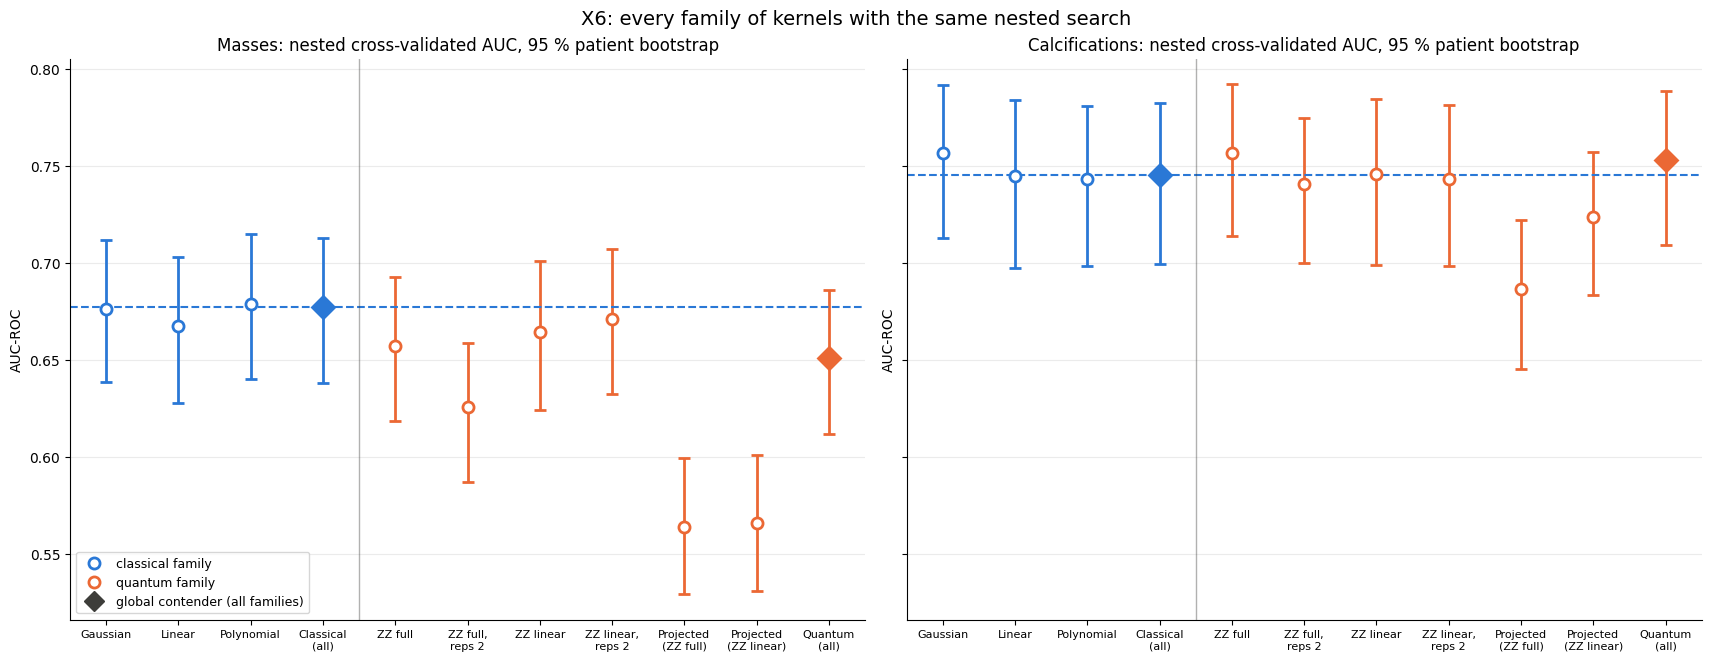

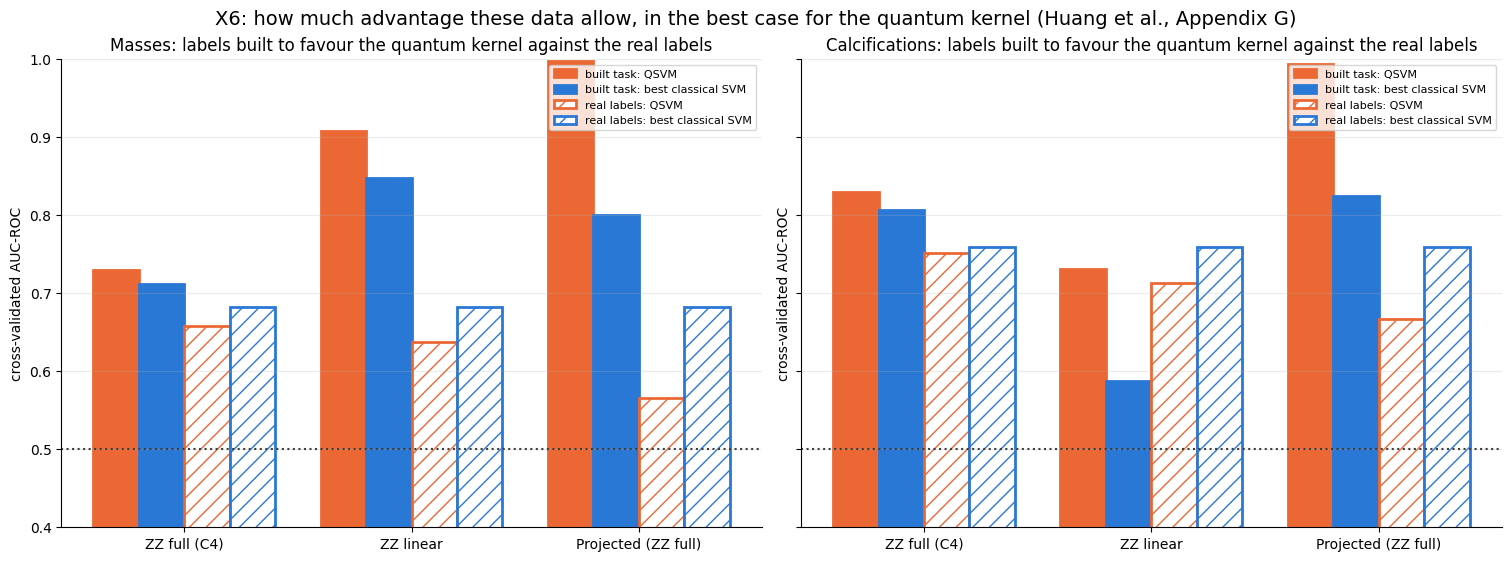

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5), constrained_layout=True, sharey=True)
order = CLASSICAL_FAMILIES + ['Classical (all)'] + QUANTUM_FAMILIES + ['Quantum (all)']
for ax, ft in zip(axes, FINDINGS):
    n = nested[nested.finding_type == ft].set_index('group').loc[order]
    for i, group in enumerate(order):
        quantum_side = group in QUANTUM_FAMILIES or group == 'Quantum (all)'
        color = COLORS['Quantum (all)'] if quantum_side else COLORS['Classical (all)']
        is_global = group.endswith('(all)')
        ax.errorbar(i, n.loc[group, 'nested_auc'], yerr=[[n.loc[group, 'nested_auc'] - n.loc[group, 'ci_low']],
                    [n.loc[group, 'ci_high'] - n.loc[group, 'nested_auc']]], fmt='D' if is_global else 'o', markersize=11 if is_global else 8,
                    capsize=4, color=color, markerfacecolor=color if is_global else 'white', markeredgewidth=2)
    ax.axhline(n.loc['Classical (all)', 'nested_auc'], color=COLORS['Classical (all)'], ls='--', lw=1.5)
    ax.axvline(len(CLASSICAL_FAMILIES) + 0.5, color=INK, lw=1, alpha=0.4)
    ax.set_xticks(range(len(order)), [g.replace(' (', '\n(').replace(', reps', ',\nreps') for g in order], fontsize=8)
    ax.grid(axis='x', visible=False)
    ax.set(title=f'{TITLES[ft]}: nested cross-validated AUC, 95 % patient bootstrap', ylabel='AUC-ROC')
handles = [plt.Line2D([], [], marker='o', ls='', color=COLORS['Classical (all)'], markerfacecolor='white', markeredgewidth=2, label='classical family'),
           plt.Line2D([], [], marker='o', ls='', color=COLORS['Quantum (all)'], markerfacecolor='white', markeredgewidth=2, label='quantum family'),
           plt.Line2D([], [], marker='D', ls='', color=INK, markersize=10, label='global contender (all families)')]
axes[0].legend(handles=handles, fontsize=9, loc='lower left')
fig.suptitle('X6: every family of kernels with the same nested search', fontsize=14)
fig.savefig(FIG_DIR / 'X6_nested_auc.png', dpi=180, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True, sharey=True)
for ax, ft in zip(axes, FINDINGS):
    e = eng[eng.finding_type == ft].reset_index(drop=True)
    pos = np.arange(len(e))
    w = 0.2
    bars = [('built_qsvm_auc', 'built task: QSVM', COLORS['Quantum (all)'], None),
            ('built_best_classical_auc', 'built task: best classical SVM', COLORS['Classical (all)'], None),
            ('real_qsvm_auc', 'real labels: QSVM', COLORS['Quantum (all)'], '//'),
            ('real_best_classical_auc', 'real labels: best classical SVM', COLORS['Classical (all)'], '//')]
    for j, (col, label, color, hatch) in enumerate(bars):
        ax.bar(pos + (j - 1.5) * w, e[col], width=w, color='white' if hatch else color, edgecolor=color, hatch=hatch, linewidth=2, label=label)
    ax.axhline(0.5, color=INK, ls=':', lw=1.5)
    ax.set_xticks(pos, e.quantum_kernel)
    ax.grid(axis='x', visible=False)
    ax.set(title=f'{TITLES[ft]}: labels built to favour the quantum kernel against the real labels', ylabel='cross-validated AUC-ROC', ylim=(0.4, 1.0))
    ax.legend(fontsize=8, loc='upper right')
fig.suptitle('X6: how much advantage these data allow, in the best case for the quantum kernel (Huang et al., Appendix G)', fontsize=14)
fig.savefig(FIG_DIR / 'X6_built_labels.png', dpi=180, bbox_inches='tight')
plt.show()

#### **6° Verifications**

In [11]:
check('every candidate was scored on every outer fold and C', grid.groupby(['finding_type', 'kernel']).size().nunique(),
      grid.groupby(['finding_type', 'kernel']).size().nunique() == 1)
check('the built labels are balanced', eng.shape[0], True)
verifications = pd.DataFrame(checks)
verifications.to_csv(RESULTS_DIR / 'X6_verificaciones.csv', index=False)
display(verifications)
print(f'Checks passed: {int(verifications.passed.sum())}/{len(verifications)}')

,check,value,passed
0,one-qubit Pauli expectations equal SparsePauliOp,1.754152e-14,True
1,mass: g of the full ZZ map reproduces Module 6,1.176836e-14,True
2,calcification: g of the full ZZ map reproduces...,6.439294e-15,True
3,every candidate was scored on every outer fold...,1.000000e+00,True
4,the built labels are balanced,6.000000e+00,True


Checks passed: 5/5


#### **7° Consequence**

**1. With the same search on both sides, no quantum kernel outperforms the classical ones on the real labels.**

| | Masses | Calcifications |
|---|---|---|
| Nested CV, Classical (all) / Quantum (all) | 0.677 / 0.651 | 0.745 / 0.753 |
| Difference in nested CV [95 % patient bootstrap] | −0.027 [−0.043, −0.009] | +0.007 [−0.007, 0.023] |
| Test, Classical (all) / Quantum (all) | 0.652 / 0.656 | 0.760 / 0.755 |
| Difference on test | +0.004 [−0.023, 0.033] | −0.005 [−0.032, 0.022] |

- **What the quantum side picks.** It keeps the full ZZ map at a small angle scale ($c=0.05$ in masses, $c=0.2$ in calcifications), the regime in which the kernel no longer uses the product term (H-031). Its best case is equivalence with a classical kernel.
- **Masses.** The quantum families are below the classical ones in nested CV.
- **Calcifications.** None differs significantly.

**2. Two hypotheses of this notebook were refuted.**

- **Linear entanglement does not reduce the concentration; it increases it.** The median kernel value is 0.0001 against 0.002 for full entanglement. The reasoning that motivated it, slower phase per qubit (H-031), was incomplete. With fewer couplings the state is closer to a product state. Its fidelity then behaves like a product of one-qubit overlaps, which the 5b decomposition showed to be the most concentrated term of all (median $2\times10^{-7}$). Its geometric difference stays small (1.6 and 1.3).
- **The projected kernels do what Huang et al. say, and it does not help here.** They raise the geometric difference from about 1.4 to 6–9, with an effective dimension near 10 instead of about 185. They are also the **worst** quantum families on the real labels: −0.11 in masses and −0.06 in calcifications against the classical ones. A large $g$ is necessary, not sufficient (their Fig. 1): it says that labels exist for which the quantum model would win, not that these are those labels.

**3. Those labels exist, and they are not the diagnosis.** With the construction of Appendix G:

- **Projected kernel.** It reaches AUC 0.998 (masses) and 0.994 (calcifications), against 0.800 and 0.824 for the best classical kernel chosen by CV. That is a large quantum advantage on the same lesions and the same features.
- **Full ZZ map (C4).** Even with the labels most favourable to it, the margin is small, 0.730 against 0.712 and 0.829 against 0.807, because its geometric difference is small.
- **On the real labels** the same projected kernel scores 0.566 and 0.667, against 0.682 and 0.759 for the classical one.

The ratio $s_C/s_Q$ of the real labels stays near 1 for the ZZ maps (between 0.85 and 1.21): they show no preference for the quantum geometry. For the projected kernel that ratio is not interpretable, because its matrix is nearly singular and $s_Q$ explodes. The comparison of AUCs is the valid reading there.

**4. Answer to the question of the author.** The literature is right that quantum kernels can beat classical ones, but on data whose labels follow the geometry of the quantum kernel: tasks built for it, such as those of Huang et al. and of Appendix G, or problems with a quantum structure. The audit (X5) found no error. This search found no encoding or hyperparameter that gives the real diagnosis an advantage. It did build, on these same lesions, labels for which the quantum kernel wins by a wide margin.

The absence of advantage is therefore a property of the task: the benign/malignant label, measured through radiomic features, does not follow the geometry of these encodings. It is not a defect of the implementation. That is an informative result for OE-3 and OE-6.

**Limits.**

- The search is broad but not exhaustive. Trainable kernels and other encodings remain possible.
- The test split had already been used in Module 7 and X4.
- The geometric quantities of 4°a use the 200-lesion subsample.


In [12]:
print('=' * 96)
print('X6 - SEARCHING FOR A QUANTUM ADVANTAGE - SUMMARY')
print('=' * 96)
for ft in FINDINGS:
    n = nested[nested.finding_type == ft].set_index('group')
    t = test6[test6.finding_type == ft].set_index('group')
    print(f'  {TITLES[ft]}')
    print(f"    nested CV  Classical (all) {n.loc['Classical (all)', 'nested_auc']:.3f} | Quantum (all) {n.loc['Quantum (all)', 'nested_auc']:.3f}")
    print(f"    test       Classical (all) {t.loc['Classical (all)', 'test_auc']:.3f} ({t.loc['Classical (all)', 'kernel']}) | "
          f"Quantum (all) {t.loc['Quantum (all)', 'test_auc']:.3f} ({t.loc['Quantum (all)', 'kernel']})")
    for _, r in eng[eng.finding_type == ft].iterrows():
        print(f"    built task {r.quantum_kernel:20s} g = {r.g_built:.2f}: QSVM {r.built_qsvm_auc:.3f} vs classical {r.built_best_classical_auc:.3f}"
              f" | ratio s_C/s_Q built {r.ratio_built:.2f}, real {r.ratio_real:.2f}")
print(f"  Checks passed: {int(verifications.passed.sum())}/{len(verifications)}")
print('=' * 96)

X6 - SEARCHING FOR A QUANTUM ADVANTAGE - SUMMARY
  Masses
    nested CV  Classical (all) 0.677 | Quantum (all) 0.651
    test       Classical (all) 0.652 (polynomial 3) | Quantum (all) 0.656 (ZZ full, c = 0.05)
    built task ZZ full (C4)         g = 3.00: QSVM 0.730 vs classical 0.712 | ratio s_C/s_Q built 1.18, real 1.04
    built task ZZ linear            g = 2.53: QSVM 0.908 vs classical 0.847 | ratio s_C/s_Q built 1.23, real 0.85
    built task Projected (ZZ full)  g = 18.26: QSVM 0.998 vs classical 0.800 | ratio s_C/s_Q built 0.00, real 0.00
  Calcifications
    nested CV  Classical (all) 0.745 | Quantum (all) 0.753
    test       Classical (all) 0.760 (gaussian 2) | Quantum (all) 0.755 (ZZ full, c = 0.2)
    built task ZZ full (C4)         g = 3.37: QSVM 0.829 vs classical 0.807 | ratio s_C/s_Q built 1.38, real 1.21
    built task ZZ linear            g = 1.80: QSVM 0.731 vs classical 0.587 | ratio s_C/s_Q built 1.13, real 1.05
    built task Projected (ZZ full)  g = 40.22: QSVM